# final7 — 완전관측 baseline

36개월 완전관측 데이터 + 기존 법인데이터 원본 변수 기반 baseline입니다. **거래건수 계열은 y 생성 직접 재료이므로 모델 feature에서 제거**합니다.

## STEP 0. 라이브러리

In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib

from IPython.display import display

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    f1_score,
    recall_score,
    precision_score,
    precision_recall_curve,
    confusion_matrix,
    accuracy_score,
)

try:
    from lightgbm import LGBMClassifier
except ImportError as e:
    raise ImportError("lightgbm이 설치되어 있어야 합니다. `pip install lightgbm` 후 다시 실행하세요.") from e

matplotlib.rcParams['font.family'] = 'Malgun Gothic'   # Mac: 'AppleGothic'
matplotlib.rcParams['axes.unicode_minus'] = False

EPS = 1e-6
EPS2 = 1e-9
RANDOM_STATE = 42
DATA_PATH = '36.csv'
NOTEBOOK_NAME = 'final7'

print(f'NOTEBOOK_NAME = {NOTEBOOK_NAME}')

NOTEBOOK_NAME = final7


## STEP 1. 데이터 로드 + 정렬

In [2]:
import os
import pandas as pd

df = pd.read_csv('iM_edu.csv')

# 기준년월 정리
df['기준년월'] = (
    df['기준년월']
    .astype(str)
    .str.replace('-', '', regex=False)
    .str.slice(0, 6)
)

# 전체 데이터 월 수 확인
print('전체 기준년월 수:', df['기준년월'].nunique())
print('기간:', df['기준년월'].min(), '~', df['기준년월'].max())

# 법인별 관측 월 수
_cnt = df.groupby('법인ID')['기준년월'].nunique()

# 36개월 완전관측 법인만
_full = set(_cnt[_cnt == 36].index)

df = df[df['법인ID'].isin(_full)].copy()
df = df.sort_values(['법인ID', '기준년월']).reset_index(drop=True)

print('36개월 완전관측 로드:', df.shape, '| 법인', df['법인ID'].nunique())
print('법인별 월 수 확인:')
display(df.groupby('법인ID')['기준년월'].nunique().value_counts().sort_index())

전체 기준년월 수: 36
기간: 202301 ~ 202512
36개월 완전관측 로드: (121392, 70) | 법인 3372
법인별 월 수 확인:


기준년월
36    3372
Name: count, dtype: int64

## STEP 2. 전처리 (수치화 + 결측 처리만)

In [3]:
# ── 2-1. 구간 문자열(좌수/거래건수) → 수치 ──
def parse_count_str(s):
    if pd.isna(s) or str(s) in ['', '-']: return 0
    s = str(s)
    e = re.match(r'^(\d+)[개건]$', s)
    if e: return int(e.group(1))
    b = re.match(r'^(\d+)[개건]초과\s*(\d+)[개건]이하$', s)
    if b: return int(b.group(1)) + 1
    o = re.match(r'^(\d+)[개건]\s*초과$', s)
    if o: return int(o.group(1)) + 1
    return 0
for c in [col for col in df.columns if '좌수' in col or '거래건수' in col or '개수' in col]:
    df[c + '_num'] = df[c].apply(parse_count_str)

# ── 2-2. 결측치 처리 ──
df['지역_결측_여부'] = df['사업장_시도'].isna().astype(int)
df['사업장_시도']   = df['사업장_시도'].fillna('Unknown')
df['사업장_시군구'] = df['사업장_시군구'].fillna('Unknown')
num_cols = df.select_dtypes(include=[np.number]).columns
df[num_cols] = df[num_cols].fillna(0)
print(f"전처리 완료 | 잔여 결측: {df.isnull().sum().sum()}")


전처리 완료 | 잔여 결측: 0


## STEP 3. 타겟 변수(y) 생성 — 1개월 SHIFT 선행 타깃 적용 (X_t → y_{t+1})

In [4]:
# ============================================================
# STEP 3. 타겟 변수 생성 + 1개월 SHIFT 선행 타깃  (X_t -> y_{t+1})
#  - y_current : 해당 월 거래활동성 약화 여부 (기존 final7 정의)
#  - y_next1   : 다음 월 거래활동성 약화 여부 (현재 피처로 예측)
#  - 모델 학습용 df_model['y'] 는 y_next1 로 교체 (진짜 '조기' 예측)
# ============================================================

# 논문 Frequency 지표 / 거래활동성 약화 proxy 라벨 재료 (거래건수 수치화 컬럼)
freq_num_cols = ['창구거래건수_num','인터넷뱅킹거래건수_num','스마트뱅킹거래건수_num',
                 '폰뱅킹거래건수_num','ATM거래건수_num','자동이체거래건수_num']
missing_freq_cols = [c for c in freq_num_cols if c not in df.columns]
if missing_freq_cols:
    raise ValueError(f'거래건수 수치화 컬럼이 없습니다: {missing_freq_cols}')

df = df.sort_values(['법인ID', '기준년월']).copy().reset_index(drop=True)
df['총거래건수'] = df[freq_num_cols].sum(axis=1)

# 조건1: 거래빈도 이동 구간 변화율 (현재 row 직전 6개월 흐름 요약)
def compute_rolling_change(series, past=3, recent=3):
    n = len(series); M = np.full(n, np.nan)
    for i in range(past + recent, n):
        ps = series.iloc[i-past-recent : i-recent].sum()   # 이전 3개월
        rs = series.iloc[i-recent : i].sum()               # 최근 3개월
        M[i] = (rs - ps) / (ps + EPS)
    return M
df['M_freq'] = df.groupby('법인ID')['총거래건수'].transform(
    lambda x: compute_rolling_change(x.reset_index(drop=True)))

# 조건2: 거래 규칙성 (변동계수)
def rolling_cv(series, window=6):
    m = series.rolling(window, min_periods=3).mean()
    sd = series.rolling(window, min_periods=3).std()
    return sd / (m + EPS)
df['freq_CV'] = df.groupby('법인ID')['총거래건수'].transform(
    lambda x: rolling_cv(x.reset_index(drop=True)).values)

# 현재월 거래활동성 약화 여부 (y_current) — warm-up(최초 6개월)은 플래그로 분리
df['y_available'] = df['M_freq'].notna() & df['freq_CV'].notna()
CV_BASELINE = df.loc[df['y_available'], 'freq_CV'].mean()
df['y_current'] = np.nan
df.loc[df['y_available'], 'y_current'] = (
    (df.loc[df['y_available'], 'M_freq'] <= -0.30) |
    (df.loc[df['y_available'], 'freq_CV'] > CV_BASELINE)
).astype(int)

# ── 1개월 SHIFT: X_t -> y_next1 = y_current_{t+1} ──
df['y_next1'] = df.groupby('법인ID')['y_current'].shift(-1)
df['target_기준년월'] = df.groupby('법인ID')['기준년월'].shift(-1)

# 전체 df의 'y'는 기존 final7와 동일하게 현재월 라벨로 유지(백워드 호환)
df['y'] = df['y_current']

# 모델링 행: 현재월 피처 안정(y_available) & 다음월 타깃 존재(y_next1 notna)
model_mask = df['y_available'] & df['y_next1'].notna()
df_model = df.loc[model_mask].copy().reset_index(drop=True)

# 모델 학습 target 을 '다음월 약화 여부'로 교체 (downstream target_col='y' 그대로 호환)
df_model['y'] = df_model['y_next1'].astype(int)
df_model['y_current'] = df_model['y_current'].astype(int)

print('=' * 70)
print('Y 1개월 SHIFT 타깃 생성 완료   (X_t -> y_{t+1})')
print('=' * 70)
print('전체 df shape:', df.shape)
print('모델링 df_model shape:', df_model.shape)
print('warm-up 행 수:', int((~df['y_available']).sum()))
print('다음월 y 없음으로 제외된 행 수:', int((df['y_available'] & df['y_next1'].isna()).sum()))
print('X 기준월 범위    :', df_model['기준년월'].min(), '~', df_model['기준년월'].max())
print('Target 기준월 범위:', df_model['target_기준년월'].min(), '~', df_model['target_기준년월'].max())
print('\n[y_next1 분포 = 모델 학습 target y]')
print(df_model['y'].value_counts())
print(df_model['y'].value_counts(normalize=True))


Y 1개월 SHIFT 타깃 생성 완료   (X_t -> y_{t+1})
전체 df shape: (121392, 108)
모델링 df_model shape: (97788, 108)
warm-up 행 수: 20232
다음월 y 없음으로 제외된 행 수: 3372
X 기준월 범위    : 202307 ~ 202511
Target 기준월 범위: 202308 ~ 202512

[y_next1 분포 = 모델 학습 target y]
y
0    58131
1    39657
Name: count, dtype: int64
y
0    0.594459
1    0.405541
Name: proportion, dtype: float64


In [5]:
# 진단: '현재월' 약화(y_current) 조건 분해 — 이 라벨을 1개월 SHIFT 한 것이 모델 타깃 y(=y_next1)
cond_m  = df_model['M_freq'] <= -0.30
cond_cv = df_model['freq_CV'] > CV_BASELINE
print('[현재월 y_current 조건 분해]')
print('  M_freq 감소(<=-30%):', cond_m.sum(), round(cond_m.mean(), 4))
print('  freq_CV 초과       :', cond_cv.sum(), round(cond_cv.mean(), 4))
print('  둘 다 해당         :', (cond_m & cond_cv).sum())
print('  M만 해당:', (cond_m & ~cond_cv).sum(), '| CV만 해당:', (~cond_m & cond_cv).sum())
print('\n[모델 타깃 y(=다음월 y_next1) 분포]')
print('  현재월 y_current=1 비율:', round(df_model['y_current'].mean(), 4))
print('  다음월 y       =1 비율:', round(df_model['y'].mean(), 4))


[현재월 y_current 조건 분해]
  M_freq 감소(<=-30%): 4905 0.0502
  freq_CV 초과       : 39314 0.402
  둘 다 해당         : 4684
  M만 해당: 221 | CV만 해당: 34630

[모델 타깃 y(=다음월 y_next1) 분포]
  현재월 y_current=1 비율: 0.4043
  다음월 y       =1 비율: 0.4055


In [6]:
# # ============================================================
# # y 기준 여러 버전 비교
# # ============================================================

# cv_mean = df_model['freq_CV'].mean()
# cv_q75 = df_model['freq_CV'].quantile(0.75)
# cv_q80 = df_model['freq_CV'].quantile(0.80)

# df_model['y_old'] = (
#     (df_model['M_freq'] <= -0.30) |
#     (df_model['freq_CV'] > cv_mean)
# ).astype(int)

# df_model['y_v2'] = (
#     (df_model['M_freq'] <= -0.30) |
#     (
#         (df_model['M_freq'] <= -0.15) &
#         (df_model['freq_CV'] >= cv_q75)
#     )
# ).astype(int)

# df_model['y_v3'] = (
#     (df_model['M_freq'] <= -0.30) |
#     (
#         (df_model['M_freq'] <= -0.10) &
#         (df_model['freq_CV'] >= cv_q80)
#     )
# ).astype(int)

# summary = []

# for col in ['y_old', 'y_v2', 'y_v3']:
#     vc = df_model[col].value_counts()
#     vr = df_model[col].value_counts(normalize=True)
    
#     summary.append({
#         'label': col,
#         'y0_count': vc.get(0, 0),
#         'y1_count': vc.get(1, 0),
#         'y0_rate': vr.get(0, 0),
#         'y1_rate': vr.get(1, 0)
#     })

# y_compare = pd.DataFrame(summary)
# display(y_compare)

In [7]:
# 법인별 위험 신호 발생 월 수
corp_risk_summary = (
    df_model
    .groupby('법인ID')
    .agg(
        total_months=('y', 'size'),
        risk_months=('y', 'sum'),
        risk_rate=('y', 'mean'),
        ever_risk=('y', 'max')
    )
    .reset_index()
)

display(corp_risk_summary['risk_months'].describe())
display(corp_risk_summary['risk_rate'].describe())

print('한 번이라도 위험 신호 발생 법인 비율')
print(corp_risk_summary['ever_risk'].mean())

print('위험 신호 월 수 분포')
display(corp_risk_summary['risk_months'].value_counts().sort_index())

count    3372.000000
mean       11.760676
std        10.875633
min         0.000000
25%         0.000000
50%        10.000000
75%        22.000000
max        29.000000
Name: risk_months, dtype: float64

count    3372.000000
mean        0.405541
std         0.375022
min         0.000000
25%         0.000000
50%         0.344828
75%         0.758621
max         1.000000
Name: risk_rate, dtype: float64

한 번이라도 위험 신호 발생 법인 비율
0.6871293001186239
위험 신호 월 수 분포


risk_months
0     1055
1       57
2       71
3       65
4       74
5       62
6       84
7       60
8       71
9       50
10      58
11      72
12      66
13      65
14      68
15      64
16      55
17      82
18      68
19      60
20      76
21      73
22      99
23      89
24      84
25      70
26      81
27      95
28     101
29     297
Name: count, dtype: int64

In [8]:
def max_consecutive_ones(s):
    max_run = 0
    cur = 0
    for v in s:
        if v == 1:
            cur += 1
            max_run = max(max_run, cur)
        else:
            cur = 0
    return max_run

corp_streak = (
    df_model
    .sort_values(['법인ID', '기준년월'])
    .groupby('법인ID')['y']
    .apply(max_consecutive_ones)
    .reset_index(name='max_risk_streak')
)

display(corp_streak['max_risk_streak'].describe())
display(corp_streak['max_risk_streak'].value_counts().sort_index())

count    3372.000000
mean        8.940688
std         9.466927
min         0.000000
25%         0.000000
50%         6.000000
75%        14.000000
max        29.000000
Name: max_risk_streak, dtype: float64

max_risk_streak
0     1055
1       73
2      113
3       78
4      111
5      103
6      243
7      109
8      101
9      101
10      92
11     102
12      90
13      94
14      79
15      55
16      66
17      56
18      47
19      42
20      44
21      44
22      39
23      23
24      25
25      19
26      25
27      26
28      20
29     297
Name: count, dtype: int64

---
# PART 2. 업종별 모델링 / 통합모델 / 앙상블

- 모델링 기준 데이터: `df_model` = y가 정의 가능한 30개월
- 대상 업종: 제조업, 도매 및 소매업, 건설업, 부동산업
- 모든 메인 모델에서 거래건수 계열 feature 제거
- 범주형: OneHotEncoding
- 수치형: train 기준 clipping + log1p
- 피처선택: train 기준 corr pruning


In [9]:
# ============================================================
# PART 2 준비: top4 업종 모델링용 데이터 생성
# ============================================================

TOP4_INDS = ['제조업', '도매 및 소매업', '건설업', '부동산업']

# df_model = y_available=True인 30개월 모델링 데이터
# 모델링/라벨 EDA/Feature Importance/SHAP은 df_model 기준으로 수행한다.
dfx = (
    df_model[df_model['업종_대분류'].isin(TOP4_INDS)]
    .sort_values(['법인ID', '기준년월'])
    .reset_index(drop=True)
    .copy()
)

print('=' * 70)
print('PART 2 시작: top4 업종 모델링 데이터')
print('=' * 70)
print('dfx shape:', dfx.shape)
print('법인 수:', dfx['법인ID'].nunique())
print('기간:', dfx['기준년월'].min(), '~', dfx['기준년월'].max())
print('전체 y=1 비율: %.2f%%' % (dfx['y'].mean() * 100))
print('\n업종별 행 수')
display(dfx['업종_대분류'].value_counts().to_frame('row_count'))

PART 2 시작: top4 업종 모델링 데이터
dfx shape: (76879, 108)
법인 수: 2651
기간: 202307 ~ 202511
전체 y=1 비율: 41.62%

업종별 행 수


,row_count
업종_대분류,
제조업,31697
도매 및 소매업,20474
건설업,16907
부동산업,7801


## 2-1. 0비율 처리

100% 0 변수는 제거하고, 0 비율이 85% 이상 100% 미만인 수치형 변수는 `zero/nonzero` 범주형 변수로 변환한다.

In [10]:
PROTECTED_COLS = ['법인ID','기준년월','기준년월_dt','y','y_available','M_freq','freq_CV','총거래건수',
                  'y_current','y_next1','target_기준년월']

# 5-1. 100% 0 변수 제거
zero_ratio = (dfx.select_dtypes(include=np.number)==0).mean().sort_values(ascending=False)
print('[0비율 상위 15]'); print(zero_ratio.head(15).round(3).to_string())
zero_100_cols = [c for c in zero_ratio[zero_ratio>=1.0].index if c not in PROTECTED_COLS]
print('\n100% 0 제거:', len(zero_100_cols)); print(zero_100_cols[:30])
dfx = dfx.drop(columns=zero_100_cols, errors='ignore')
print('after 100% zero drop:', dfx.shape)

# 5-2. 0비율 85%↑ <100% → zero/nonzero 범주형
HIGH_ZERO_THRESHOLD = 0.85
zr2 = (dfx.select_dtypes(include=np.number)==0).mean().sort_values(ascending=False)
high_zero_cols = [c for c in zr2[(zr2>=HIGH_ZERO_THRESHOLD)&(zr2<1.0)].index if c not in PROTECTED_COLS]
print(f'\n0비율 {HIGH_ZERO_THRESHOLD:.0%}↑ 변수:', len(high_zero_cols)); print(high_zero_cols[:30])
high_zero_cat_cols = []
for c in high_zero_cols:
    nc = f'{c}_zero_cat'
    dfx[nc] = np.where(dfx[c].fillna(0)==0, 'zero', 'nonzero')
    high_zero_cat_cols.append(nc)
HIGH_ZERO_NUMERIC_DROP_COLS = high_zero_cols
print('생성 zero_cat:', high_zero_cat_cols[:30])

[0비율 상위 15]
시설_주택자금대출잔액            1.000
시설_주택자금대출좌수_num        1.000
운전_주택자금대출좌수_num        1.000
운전_주택자금대출잔액            1.000
운전_당좌대출잔액              0.992
운전_외상매출채권담보대출잔액        0.988
운전_무역금융잔액              0.985
운전_외상매출채권담보대출좌수_num    0.982
외환_수출실적금액              0.981
외환_수출실적거래건수_num        0.981
운전_무역금융좌수_num          0.981
수익증권잔액                 0.981
운전_당좌대출좌수_num          0.981
시설_에너지절약시설대출잔액         0.979
시설_에너지절약시설대출좌수_num     0.977

100% 0 제거: 4
['시설_주택자금대출잔액', '시설_주택자금대출좌수_num', '운전_주택자금대출좌수_num', '운전_주택자금대출잔액']
after 100% zero drop: (76879, 104)

0비율 85%↑ 변수: 30
['운전_당좌대출잔액', '운전_외상매출채권담보대출잔액', '운전_무역금융잔액', '운전_외상매출채권담보대출좌수_num', '외환_수출실적금액', '외환_수출실적거래건수_num', '운전_무역금융좌수_num', '수익증권잔액', '운전_당좌대출좌수_num', '시설_에너지절약시설대출잔액', '시설_에너지절약시설대출좌수_num', '외환_수입실적거래건수_num', '외환_수입실적금액', '운전_할인어음잔액', '수익증권좌수_num', '체크카드사용금액', '운전_기업구매자금대출잔액', '운전_할인어음좌수_num', '지역_결측_여부', '운전_기업구매자금대출좌수_num', '시설_기타시설자금대출잔액', '시설_기타시설자금대출좌수_num', '적립식예금잔액', '운전_기타운전자금대출잔액', '거치식예금잔액', '운전_기타운전자금대출좌수_num

## 2-2. Feature set 구성

거래건수 계열, 라벨 생성 변수, high-zero 원본 수치형 변수를 feature에서 제거한다.

In [11]:
# ============================================================
# Feature set 구성
# - 거래건수 계열은 y 생성 직접 재료이므로 모든 메인 모델에서 제거
# - 거래금액 계열은 직접 재료가 아니므로 유지
# - high-zero 원본 수치형 변수는 제거하고 zero/nonzero 범주형만 사용
# ============================================================

ALWAYS_EXCLUDE = [
    '법인ID', '기준년월', '기준년월_dt',
    'y', 'y_available',
    'M_freq', 'freq_CV', '총거래건수',
    'y_current', 'y_next1', 'target_기준년월'   # SHIFT 타깃 보조 컬럼 누수 차단
]

COUNT_LEAK_KW = ['거래건수', '총거래건수', 'M_freq', 'freq_CV', 'freq', 'Frequency']

count_leak_cols = [
    c for c in dfx.columns
    if any(k in c for k in COUNT_LEAK_KW)
]

print('=' * 70)
print('Feature exclusion 점검')
print('=' * 70)
print('거래건수 계열 제거 후보 수:', len(count_leak_cols))
print(count_leak_cols[:50])

# final7/final8 모두 "기존 법인데이터 모든 변수 + 필요한 확장 변수"를 유지한다.
# 따라서 합산 파생변수의 원본 재료 컬럼은 제거하지 않는다.
SUM_INGREDIENT_COLS = []

EXCLUDE_COLS = set(
    ALWAYS_EXCLUDE
    + count_leak_cols
    + HIGH_ZERO_NUMERIC_DROP_COLS
    + SUM_INGREDIENT_COLS
)

print('high-zero 원본 수치형 제거 수:', len(HIGH_ZERO_NUMERIC_DROP_COLS))
print('총 EXCLUDE 수:', len(EXCLUDE_COLS))

# 범주형 후보 + high-zero zero_cat
BASE_CAT_COLS = ['업종_대분류', '업종_중분류', '사업장_시도', '사업장_시군구']
CAT_COLS_CANDIDATE = [
    c for c in BASE_CAT_COLS + high_zero_cat_cols
    if c in dfx.columns
]

CAT_FEAT_ALL = [
    c for c in CAT_COLS_CANDIDATE
    if c not in EXCLUDE_COLS
]

NUM_FEAT_ALL = [
    c for c in dfx.columns
    if c not in EXCLUDE_COLS
    and c not in CAT_FEAT_ALL
    and pd.api.types.is_numeric_dtype(dfx[c])
]

# 결측/inf 처리
for c in CAT_FEAT_ALL:
    dfx[c] = dfx[c].fillna('Unknown').astype(str)

if len(NUM_FEAT_ALL) > 0:
    dfx[NUM_FEAT_ALL] = (
        dfx[NUM_FEAT_ALL]
        .replace([np.inf, -np.inf], np.nan)
        .fillna(0)
    )

print('\n최종 피처 수')
print('NUM_FEAT:', len(NUM_FEAT_ALL))
print('CAT_FEAT:', len(CAT_FEAT_ALL))
print('CAT_FEAT 목록:', CAT_FEAT_ALL[:30])

# 거래건수 누수 검증
leak = [
    c for c in NUM_FEAT_ALL + CAT_FEAT_ALL
    if any(k in c for k in ['거래건수', 'M_freq', 'freq_CV'])
]
assert len(leak) == 0, f'거래건수 누수 컬럼이 feature에 남아 있습니다: {leak}'

print('거래건수 누수 없음 OK')

Feature exclusion 점검
거래건수 계열 제거 후보 수: 22
['외환_수출실적거래건수', '외환_수입실적거래건수', '창구거래건수', '인터넷뱅킹거래건수', '스마트뱅킹거래건수', '폰뱅킹거래건수', 'ATM거래건수', '자동이체거래건수', '외환_수출실적거래건수_num', '외환_수입실적거래건수_num', '창구거래건수_num', '인터넷뱅킹거래건수_num', '스마트뱅킹거래건수_num', '폰뱅킹거래건수_num', 'ATM거래건수_num', '자동이체거래건수_num', '총거래건수', 'M_freq', 'freq_CV', '외환_수출실적거래건수_num_zero_cat', '외환_수입실적거래건수_num_zero_cat', '폰뱅킹거래건수_num_zero_cat']
high-zero 원본 수치형 제거 수: 30
총 EXCLUDE 수: 57

최종 피처 수
NUM_FEAT: 24
CAT_FEAT: 31
CAT_FEAT 목록: ['업종_대분류', '업종_중분류', '사업장_시도', '사업장_시군구', '운전_당좌대출잔액_zero_cat', '운전_외상매출채권담보대출잔액_zero_cat', '운전_무역금융잔액_zero_cat', '운전_외상매출채권담보대출좌수_num_zero_cat', '외환_수출실적금액_zero_cat', '운전_무역금융좌수_num_zero_cat', '수익증권잔액_zero_cat', '운전_당좌대출좌수_num_zero_cat', '시설_에너지절약시설대출잔액_zero_cat', '시설_에너지절약시설대출좌수_num_zero_cat', '외환_수입실적금액_zero_cat', '운전_할인어음잔액_zero_cat', '수익증권좌수_num_zero_cat', '체크카드사용금액_zero_cat', '운전_기업구매자금대출잔액_zero_cat', '운전_할인어음좌수_num_zero_cat', '지역_결측_여부_zero_cat', '운전_기업구매자금대출좌수_num_zero_cat', '시설_기타시설자금대출잔액_zero_cat', '시설_기타시설자금대출

## 단계2 — train/valid/test 시간 분할

In [12]:
# ============================================================
# 기준년월 타입 정리 후 Train / Valid / Test split
# - test: 2025.10 ~ 2025.12
# - valid: test 제외 후 가장 최근 3개월
# - train: 나머지
# ============================================================

dfx = dfx.copy()

# 기준년월을 int YYYYMM으로 통일
dfx['기준년월'] = (
    dfx['기준년월']
    .astype(str)
    .str.replace('-', '', regex=False)
    .str.replace('.', '', regex=False)
    .str.slice(0, 6)
    .astype(int)
)

print('dfx 기준년월 dtype:', dfx['기준년월'].dtype)
print('dfx 기준년월 범위:', dfx['기준년월'].min(), '~', dfx['기준년월'].max())
print('dfx 기준년월 unique:')
print(sorted(dfx['기준년월'].unique()))

# test month 설정
test_months_p2 = [202510, 202511, 202512]

# test mask
_test_mask = dfx['기준년월'].isin(test_months_p2)

# test 제외한 나머지에서 valid 최근 3개월 설정
_train_valid_mask = ~_test_mask
valid_months = sorted(dfx.loc[_train_valid_mask, '기준년월'].unique())[-3:]

# split
df_train = dfx[_train_valid_mask & ~dfx['기준년월'].isin(valid_months)].copy()
df_valid = dfx[_train_valid_mask &  dfx['기준년월'].isin(valid_months)].copy()
df_test  = dfx[_test_mask].copy()

print('\n[Split month]')
print('Train months:', df_train['기준년월'].min(), '~', df_train['기준년월'].max())
print('Valid months:', sorted(df_valid['기준년월'].unique()))
print('Test months :', sorted(df_test['기준년월'].unique()))

print('\n[Split size]')
print(
    f'Train {len(df_train):,} '
    f'(위험군 {df_train["y"].mean()*100:.1f}%) | '
    f'Valid {len(df_valid):,} '
    f'(위험군 {df_valid["y"].mean()*100:.1f}%) | '
    f'Test {len(df_test):,} '
    f'(위험군 {df_test["y"].mean()*100:.1f}%)'
)

print('\n[업종별 split row 수]')
split_ind_cnt = pd.DataFrame({
    'train': df_train['업종_대분류'].value_counts(),
    'valid': df_valid['업종_대분류'].value_counts(),
    'test': df_test['업종_대분류'].value_counts()
}).fillna(0).astype(int)

display(split_ind_cnt)

dfx 기준년월 dtype: int32
dfx 기준년월 범위: 202307 ~ 202511
dfx 기준년월 unique:
[202307, 202308, 202309, 202310, 202311, 202312, 202401, 202402, 202403, 202404, 202405, 202406, 202407, 202408, 202409, 202410, 202411, 202412, 202501, 202502, 202503, 202504, 202505, 202506, 202507, 202508, 202509, 202510, 202511]

[Split month]
Train months: 202307 ~ 202506
Valid months: [202507, 202508, 202509]
Test months : [202510, 202511]

[Split size]
Train 63,624 (위험군 41.1%) | Valid 7,953 (위험군 43.6%) | Test 5,302 (위험군 45.4%)

[업종별 split row 수]


,train,valid,test
업종_대분류,,,
제조업,26232,3279,2186
도매 및 소매업,16944,2118,1412
건설업,13992,1749,1166
부동산업,6456,807,538


In [13]:
# ============================================================
# split sanity check
# ============================================================

assert len(df_train) > 0, 'df_train이 비어 있습니다.'
assert len(df_valid) > 0, 'df_valid가 비어 있습니다.'
assert len(df_test) > 0, 'df_test가 비어 있습니다. 기준년월 타입 또는 test_months를 확인하세요.'

assert set(df_train['기준년월']).isdisjoint(set(df_valid['기준년월']))
assert set(df_train['기준년월']).isdisjoint(set(df_test['기준년월']))
assert set(df_valid['기준년월']).isdisjoint(set(df_test['기준년월']))

print('split sanity check 통과')

split sanity check 통과


## 3-1. 전처리 함수

train 기준 clipping/log1p, corr pruning, OneHotEncoder 기반 pipeline을 정의한다.

In [14]:
# ============================================================
# 전처리 함수
# - train 기준 clipping/log1p
# - train 기준 corr pruning
# - OneHotEncoder
# ============================================================

LOW_Q, HIGH_Q = 0.005, 0.995
CORR_THRESHOLD = 0.90

LOG_KW = [
    '금액', '잔액', '실적', '사용액', '한도',
    '총예금', '총여신', '총투자', '총거래',
    '비대면거래금액', '창구거래금액', '자동이체금액'
]

NO_LOG_KW = [
    '비중', '비율', '전환율', 'CV', 'pct', 'diff',
    '감소여부', '연속하락기간', 'accel', 'HHI', '엔트로피',
    '_X_', '_BUT_'
]

def is_log_target(col):
    has_log_kw = any(k in col for k in LOG_KW)
    has_no_log_kw = any(k in col for k in NO_LOG_KW)
    return has_log_kw and not has_no_log_kw

def fit_clip(Xtr, cols):
    bounds = {}
    for c in cols:
        s = (
            pd.to_numeric(Xtr[c], errors='coerce')
            .replace([np.inf, -np.inf], np.nan)
            .fillna(0)
        )
        lo = s.quantile(LOW_Q)
        hi = s.quantile(HIGH_Q)

        if pd.isna(lo):
            lo = 0
        if pd.isna(hi):
            hi = 0
        if lo > hi:
            lo, hi = hi, lo

        bounds[c] = (lo, hi)
    return bounds

def apply_clip_log(X, cols, bounds, logset):
    X = X.copy()
    for c in cols:
        X[c] = (
            pd.to_numeric(X[c], errors='coerce')
            .replace([np.inf, -np.inf], np.nan)
            .fillna(0)
        )
        lo, hi = bounds.get(c, (X[c].min(), X[c].max()))
        X[c] = X[c].clip(lo, hi)

        if c in logset:
            X[c] = np.log1p(np.maximum(X[c], 0))
    return X

def corr_prune(Xtr, cols, thr=CORR_THRESHOLD):
    cols = [c for c in cols if c in Xtr.columns]

    if len(cols) <= 1:
        return cols, []

    Xc = (
        Xtr[cols]
        .replace([np.inf, -np.inf], np.nan)
        .fillna(0)
    )

    cm = Xc.corr().abs().fillna(0)
    upper = cm.where(np.triu(np.ones(cm.shape), k=1).astype(bool))

    miss = Xtr[cols].isna().mean().fillna(0)
    var = Xc.var().fillna(0)

    drop = set()

    for col in upper.columns:
        high_corr_rows = upper.index[upper[col] > thr].tolist()

        for row in high_corr_rows:
            if row in drop or col in drop:
                continue

            if miss[row] != miss[col]:
                drop.add(row if miss[row] > miss[col] else col)
            elif var[row] != var[col]:
                drop.add(row if var[row] < var[col] else col)
            else:
                drop.add(col)

    kept = [c for c in cols if c not in drop]
    dropped = [c for c in cols if c in drop]

    return kept, dropped

def make_ohe():
    try:
        return OneHotEncoder(handle_unknown='ignore', sparse_output=True)
    except TypeError:
        return OneHotEncoder(handle_unknown='ignore', sparse=True)

def build_pipeline(num_cols, cat_cols, params):
    transformers = []

    if len(cat_cols) > 0:
        transformers.append(('cat', make_ohe(), cat_cols))

    if len(num_cols) > 0:
        transformers.append(('num', 'passthrough', num_cols))

    pre = ColumnTransformer(transformers)

    return Pipeline([
        ('prep', pre),
        ('model', LGBMClassifier(
            **params,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbose=-1
        ))
    ])

def best_threshold(y_true, proba):
    p, r, t = precision_recall_curve(y_true, proba)
    f1 = 2 * p * r / (p + r + 1e-10)

    if len(t) == 0:
        return 0.5

    return float(t[np.argmax(f1[:-1])])

def eval_all(y, proba, thr):
    pred = (proba >= thr).astype(int)

    return {
        'ROC_AUC': roc_auc_score(y, proba) if len(np.unique(y)) > 1 else 0.5,
        'PR_AUC': average_precision_score(y, proba) if len(np.unique(y)) > 1 else 0.0,
        'F1': f1_score(y, pred, zero_division=0),
        'Recall': recall_score(y, pred, zero_division=0),
        'Precision': precision_score(y, pred, zero_division=0),
        'Accuracy': accuracy_score(y, pred),
        'CM': confusion_matrix(y, pred).tolist()
    }

LGBM_PARAMS = {
    'n_estimators': 500,
    'learning_rate': 0.05,
    'max_depth': 6,
    'num_leaves': 31,
}

print('전처리/모델링 유틸 준비 완료')
print(f'clip: {LOW_Q:.3f}~{HIGH_Q:.3f} | corr threshold: {CORR_THRESHOLD:.2f}')

전처리/모델링 유틸 준비 완료
clip: 0.005~0.995 | corr threshold: 0.90


In [15]:
def make_ohe():
    try: return OneHotEncoder(handle_unknown='ignore', sparse_output=True)
    except TypeError: return OneHotEncoder(handle_unknown='ignore', sparse=True)

def build_pipeline(num_cols, cat_cols, params):
    if cat_cols:
        pre = ColumnTransformer([('cat', make_ohe(), cat_cols), ('num','passthrough', num_cols)])
    else:
        pre = ColumnTransformer([('num','passthrough', num_cols)])
    return Pipeline([('prep', pre), ('model', LGBMClassifier(**params, random_state=42, n_jobs=-1, verbose=-1))])

def best_threshold(y_true, proba):
    p,r,t = precision_recall_curve(y_true, proba)
    f1 = 2*p*r/(p+r+1e-10)
    return float(t[np.argmax(f1[:-1])]) if len(t)>0 else 0.5

from sklearn.metrics import confusion_matrix, accuracy_score
def eval_all(y, proba, thr):
    pred = (proba>=thr).astype(int)
    return dict(
        ROC_AUC = roc_auc_score(y,proba) if len(np.unique(y))>1 else 0.5,
        PR_AUC  = average_precision_score(y,proba) if len(np.unique(y))>1 else 0.0,
        F1=f1_score(y,pred,zero_division=0), Recall=recall_score(y,pred,zero_division=0),
        Precision=precision_score(y,pred,zero_division=0), Accuracy=accuracy_score(y,pred),
        CM=confusion_matrix(y,pred).tolist())

LGBM_PARAMS = dict(n_estimators=500, learning_rate=0.05, max_depth=6, num_leaves=31)
print('pipeline/eval 유틸 준비 완료')

pipeline/eval 유틸 준비 완료


## 단계4 — 업종별 모델 (train기준 clip/log/corr + LightGBM + valid threshold)

In [16]:
TARGET_INDS =  ['제조업', '도매 및 소매업', '건설업', '부동산업']

print('[train 업종 분포]')
display(df_train['업종_대분류'].value_counts())

print('[valid 업종 분포]')
display(df_valid['업종_대분류'].value_counts())

print('[test 업종 분포]')
display(df_test['업종_대분류'].value_counts())

for ind in TARGET_INDS:
    print(
        ind,
        'train:', len(df_train[df_train['업종_대분류'] == ind]),
        'valid:', len(df_valid[df_valid['업종_대분류'] == ind]),
        'test:', len(df_test[df_test['업종_대분류'] == ind])
    )

[train 업종 분포]


업종_대분류
제조업         26232
도매 및 소매업    16944
건설업         13992
부동산업         6456
Name: count, dtype: int64

[valid 업종 분포]


업종_대분류
제조업         3279
도매 및 소매업    2118
건설업         1749
부동산업         807
Name: count, dtype: int64

[test 업종 분포]


업종_대분류
제조업         2186
도매 및 소매업    1412
건설업         1166
부동산업         538
Name: count, dtype: int64

제조업 train: 26232 valid: 3279 test: 2186
도매 및 소매업 train: 16944 valid: 2118 test: 1412
건설업 train: 13992 valid: 1749 test: 1166
부동산업 train: 6456 valid: 807 test: 538


In [17]:
print('df_model shape:', df_model.shape)

print('df_model 기준년월 unique')
print(sorted(df_model['기준년월'].unique()))

print('df_train:', df_train.shape, df_train['기준년월'].min(), df_train['기준년월'].max())
print('df_valid:', df_valid.shape, df_valid['기준년월'].min(), df_valid['기준년월'].max())

if len(df_test) > 0:
    print('df_test:', df_test.shape, df_test['기준년월'].min(), df_test['기준년월'].max())
else:
    print('df_test empty:', df_test.shape)

print('\n월별 row 수')
display(df_model['기준년월'].value_counts().sort_index())

df_model shape: (97788, 108)
df_model 기준년월 unique
['202307', '202308', '202309', '202310', '202311', '202312', '202401', '202402', '202403', '202404', '202405', '202406', '202407', '202408', '202409', '202410', '202411', '202412', '202501', '202502', '202503', '202504', '202505', '202506', '202507', '202508', '202509', '202510', '202511']
df_train: (63624, 134) 202307 202506
df_valid: (7953, 134) 202507 202509
df_test: (5302, 134) 202510 202511

월별 row 수


기준년월
202307    3372
202308    3372
202309    3372
202310    3372
202311    3372
202312    3372
202401    3372
202402    3372
202403    3372
202404    3372
202405    3372
202406    3372
202407    3372
202408    3372
202409    3372
202410    3372
202411    3372
202412    3372
202501    3372
202502    3372
202503    3372
202504    3372
202505    3372
202506    3372
202507    3372
202508    3372
202509    3372
202510    3372
202511    3372
Name: count, dtype: int64

In [18]:
TARGET_INDS = ['제조업', '도매 및 소매업', '건설업', '부동산업']
IND_MODELS = {}; IND_RESULTS = []
for ind in TARGET_INDS:
    tr = df_train[df_train['업종_대분류']==ind]
    va = df_valid[df_valid['업종_대분류']==ind]
    te = df_test [df_test ['업종_대분류']==ind]
    if len(tr) < 100 or tr['y'].sum() < 20:
        print(f'[{ind}] 스킵 (train {len(tr)})'); continue

    num = list(NUM_FEAT_ALL)
    cat = [c for c in CAT_FEAT_ALL if c != '업종_대분류']   # 업종별: 업종_대분류 제외(상수)

    # train 기준 clip/log fit
    bounds = fit_clip(tr, num); logset = set(c for c in num if is_log_target(c))
    trp = apply_clip_log(tr, num, bounds, logset)
    vap = apply_clip_log(va, num, bounds, logset)
    tep = apply_clip_log(te, num, bounds, logset)

    # train 기준 corr pruning
    n_before = len(num)
    kept, dropped = corr_prune(trp[num], num)
    print(f'[{ind}] corr 제거 전 {n_before} → 후 {len(kept)} (제거 {len(dropped)})')

    pw = (tr['y']==0).sum()/max((tr['y']==1).sum(),1)
    pipe = build_pipeline(kept, cat, {**LGBM_PARAMS, 'scale_pos_weight':pw})
    pipe.fit(trp[kept+cat], tr['y'])

    pv  = pipe.predict_proba(vap[kept+cat])[:,1]
    thr = best_threshold(va['y'], pv)
    proba_te = pipe.predict_proba(tep[kept+cat])[:,1]
    m = eval_all(te['y'], proba_te, thr)

    # feature importance
    lg = pipe.named_steps['model']
    ohe = pipe.named_steps['prep'].named_transformers_.get('cat')
    names = (list(ohe.get_feature_names_out(cat)) if ohe is not None else []) + kept
    fi = pd.DataFrame({'feature':names[:len(lg.feature_importances_)],
                       'importance':lg.feature_importances_[:len(names)]}).sort_values('importance', ascending=False)

    IND_MODELS[ind] = {'pipeline':pipe,'num_features':kept,'cat_features':cat,
                       'high_zero_cat_cols':high_zero_cat_cols,'high_zero_numeric_drop_cols':HIGH_ZERO_NUMERIC_DROP_COLS,
                       'dropped_corr_features':dropped,'threshold':thr,'metrics':m,'feature_importance':fi,
                       'clip_bounds':bounds,'log_set':logset}
    IND_RESULTS.append({'업종':ind,'train':len(tr),'valid':len(va),'test':len(te),
                        'num수':len(kept),'cat수':len(cat),'corr제거':len(dropped),
                        'ROC_AUC':round(m['ROC_AUC'],4),'PR_AUC':round(m['PR_AUC'],4),
                        'F1':round(m['F1'],4),'Recall':round(m['Recall'],4),
                        'Precision':round(m['Precision'],4),'Accuracy':round(m['Accuracy'],4),'thr':round(thr,3)})
    print(f'   AUC={m["ROC_AUC"]:.4f} PR={m["PR_AUC"]:.4f} F1={m["F1"]:.4f} Recall={m["Recall"]:.4f}')

res_ind = pd.DataFrame(IND_RESULTS)
print('\n[업종별 성능]'); print(res_ind.to_string(index=False))

[제조업] corr 제거 전 24 → 후 21 (제거 3)
   AUC=0.8509 PR=0.8066 F1=0.7717 Recall=0.8621
[도매 및 소매업] corr 제거 전 24 → 후 19 (제거 5)
   AUC=0.8965 PR=0.8228 F1=0.7273 Recall=0.6929
[건설업] corr 제거 전 24 → 후 21 (제거 3)
   AUC=0.8439 PR=0.7959 F1=0.7800 Recall=0.8203
[부동산업] corr 제거 전 24 → 후 20 (제거 4)
   AUC=0.7934 PR=0.8647 F1=0.8287 Recall=0.9400

[업종별 성능]
      업종  train  valid  test  num수  cat수  corr제거  ROC_AUC  PR_AUC     F1  Recall  Precision  Accuracy   thr
     제조업  26232   3279  2186    21    30       3   0.8509  0.8066 0.7717  0.8621     0.6984    0.7699 0.370
도매 및 소매업  16944   2118  1412    19    30       5   0.8965  0.8228 0.7273  0.6929     0.7652    0.8130 0.647
     건설업  13992   1749  1166    21    30       3   0.8439  0.7959 0.7800  0.8203     0.7435    0.7770 0.478
    부동산업   6456    807   538    20    30       4   0.7934  0.8647 0.8287  0.9400     0.7410    0.7472 0.206


## 단계4 — 통합 모델 (업종_대분류 포함)

In [19]:
num = list(NUM_FEAT_ALL)
cat = list(CAT_FEAT_ALL)   # 통합: 업종_대분류 포함
INT_bounds = fit_clip(df_train, num); INT_logset = set(c for c in num if is_log_target(c))
trp = apply_clip_log(df_train, num, INT_bounds, INT_logset)
vap = apply_clip_log(df_valid, num, INT_bounds, INT_logset)
tep = apply_clip_log(df_test , num, INT_bounds, INT_logset)
INT_kept, INT_dropped = corr_prune(trp[num], num)
print(f'통합 corr 제거 {len(INT_dropped)} → 최종 num {len(INT_kept)}')
INT_cat = cat

pw = (df_train['y']==0).sum()/max((df_train['y']==1).sum(),1)
INT_PIPE = build_pipeline(INT_kept, INT_cat, {**LGBM_PARAMS,'scale_pos_weight':pw})
INT_PIPE.fit(trp[INT_kept+INT_cat], df_train['y'])
pv = INT_PIPE.predict_proba(vap[INT_kept+INT_cat])[:,1]
THR_INT = best_threshold(df_valid['y'], pv)
proba_te = INT_PIPE.predict_proba(tep[INT_kept+INT_cat])[:,1]
INT_M = eval_all(df_test['y'], proba_te, THR_INT)
print(f'[통합] AUC={INT_M["ROC_AUC"]:.4f} PR={INT_M["PR_AUC"]:.4f} F1={INT_M["F1"]:.4f} thr={THR_INT:.3f}')

통합 corr 제거 3 → 최종 num 21
[통합] AUC=0.8577 PR=0.8086 F1=0.7751 thr=0.473


## 단계4 — 앙상블 (업종 라우팅 + 통합 + 블렌딩)

In [20]:
# ============================================================
# 업종별 라우팅 + 통합모델 + 블렌딩 평가
# ============================================================

def preprocess_for_model(d, num_cols, cat_cols, bounds, logset):
    """
    학습 때와 동일하게 숫자형 clip/log 적용 + 범주형 문자열 처리
    """
    dp = apply_clip_log(d, num_cols, bounds, logset)

    for c in cat_cols:
        if c in dp.columns:
            dp[c] = dp[c].astype(str).fillna('missing')

    return dp


def routed_predict(d):
    """
    업종별 모델이 존재하는 업종은 해당 업종 모델로 예측.
    업종별 모델이 없는 경우는 NaN으로 남김.
    """
    arr = np.full(len(d), np.nan)

    for ind, info in IND_MODELS.items():
        m = (d['업종_대분류'] == ind).values

        if m.sum() == 0:
            continue

        num_cols = info['num_features']
        cat_cols = info['cat_features']
        feat = num_cols + cat_cols

        dp = preprocess_for_model(
            d.loc[m].copy(),
            num_cols=num_cols,
            cat_cols=cat_cols,
            bounds=info['clip_bounds'],
            logset=info['log_set']
        )

        arr[np.where(m)[0]] = info['pipeline'].predict_proba(dp[feat])[:, 1]

    return arr


# ============================================================
# 1. Test 예측
# ============================================================

te_routed = routed_predict(df_test)

tep_int = preprocess_for_model(
    df_test.copy(),
    num_cols=INT_kept,
    cat_cols=INT_cat,
    bounds=INT_bounds,
    logset=INT_logset
)

te_int = INT_PIPE.predict_proba(tep_int[INT_kept + INT_cat])[:, 1]

# 업종별 모델이 없는 업종은 통합모델 예측값으로 대체
nanm = np.isnan(te_routed)
te_routed[nanm] = te_int[nanm]

# 블렌딩
te_blend = 0.5 * te_routed + 0.5 * te_int


# ============================================================
# 2. Valid 예측: threshold 결정용
# ============================================================

va_routed = routed_predict(df_valid)

vap_int = preprocess_for_model(
    df_valid.copy(),
    num_cols=INT_kept,
    cat_cols=INT_cat,
    bounds=INT_bounds,
    logset=INT_logset
)

va_int = INT_PIPE.predict_proba(vap_int[INT_kept + INT_cat])[:, 1]

nanm2 = np.isnan(va_routed)
va_routed[nanm2] = va_int[nanm2]

va_blend = 0.5 * va_routed + 0.5 * va_int


# ============================================================
# 3. threshold 결정
# ============================================================

thr_r = best_threshold(df_valid['y'], va_routed)
thr_b = best_threshold(df_valid['y'], va_blend)


# ============================================================
# 4. test 성능 평가
# ============================================================

R_routed = eval_all(df_test['y'], te_routed, thr_r)
R_blend  = eval_all(df_test['y'], te_blend, thr_b)


def _row(name, m, thr):
    return {
        '모델': name,
        'ROC_AUC': round(m['ROC_AUC'], 4),
        'PR_AUC': round(m['PR_AUC'], 4),
        'F1': round(m['F1'], 4),
        'Recall': round(m['Recall'], 4),
        'Precision': round(m['Precision'], 4),
        'Accuracy': round(m['Accuracy'], 4),
        'thr': round(thr, 3)
    }


res_ens = pd.DataFrame([
    _row('업종라우팅', R_routed, thr_r),
    _row('통합', INT_M, THR_INT),
    _row('블렌딩(0.5:0.5)', R_blend, thr_b)
])

print('[앙상블/통합 성능]')
display(res_ens)

print('\n[혼동행렬]')
print('  라우팅:', R_routed['CM'])
print('  통합  :', INT_M['CM'])
print('  블렌딩:', R_blend['CM'])

[앙상블/통합 성능]


,모델,ROC_AUC,PR_AUC,F1,Recall,Precision,Accuracy,thr
0,업종라우팅,0.8603,0.8151,0.7770,0.8587,0.7095,0.7763,0.375
1,통합,0.8577,0.8086,0.7751,0.8342,0.7238,0.7803,0.473
2,블렌딩(0.5:0.5),0.8644,0.8197,0.7792,0.8288,0.7353,0.7869,0.471



[혼동행렬]
  라우팅: [[2050, 846], [340, 2066]]
  통합  : [[2130, 766], [399, 2007]]
  블렌딩: [[2178, 718], [412, 1994]]


## 5-1. SHAP / Feature Importance


[제조업] Feature Importance Top 20


,feature,importance
106,자동이체금액,1321
98,여신_운전자금대출잔액,969
99,운전_일반자금대출잔액,878
95,요구불예금잔액,875
103,인터넷뱅킹거래금액,838
107,요구불입금금액,813
96,신탁잔액,796
101,신용카드사용금액,783
100,여신_시설자금대출잔액,665
97,여신한도금액,619



[도매 및 소매업] Feature Importance Top 20


,feature,importance
86,자동이체금액,1589
75,요구불예금잔액,1327
78,여신_운전자금대출잔액,1154
87,요구불입금금액,1133
81,신용카드사용금액,1097
83,인터넷뱅킹거래금액,1046
79,운전_일반자금대출잔액,930
77,여신한도금액,757
84,스마트뱅킹거래금액,703
93,신용카드개수_num,507



[건설업] Feature Importance Top 20


,feature,importance
75,운전_일반자금대출잔액,1333
82,자동이체금액,1311
71,요구불예금잔액,1228
77,신용카드사용금액,998
84,요구불출금금액,917
74,여신한도금액,901
79,인터넷뱅킹거래금액,796
83,요구불입금금액,736
78,창구거래금액,482
72,신탁잔액,477



[부동산업] Feature Importance Top 20


,feature,importance
65,요구불예금잔액,1630
76,자동이체금액,1600
77,요구불입금금액,1127
78,요구불출금금액,1079
70,시설_일반자금대출잔액,1073
73,인터넷뱅킹거래금액,1048
69,여신_운전자금대출잔액,815
71,신용카드사용금액,652
74,스마트뱅킹거래금액,602
68,여신한도금액,374


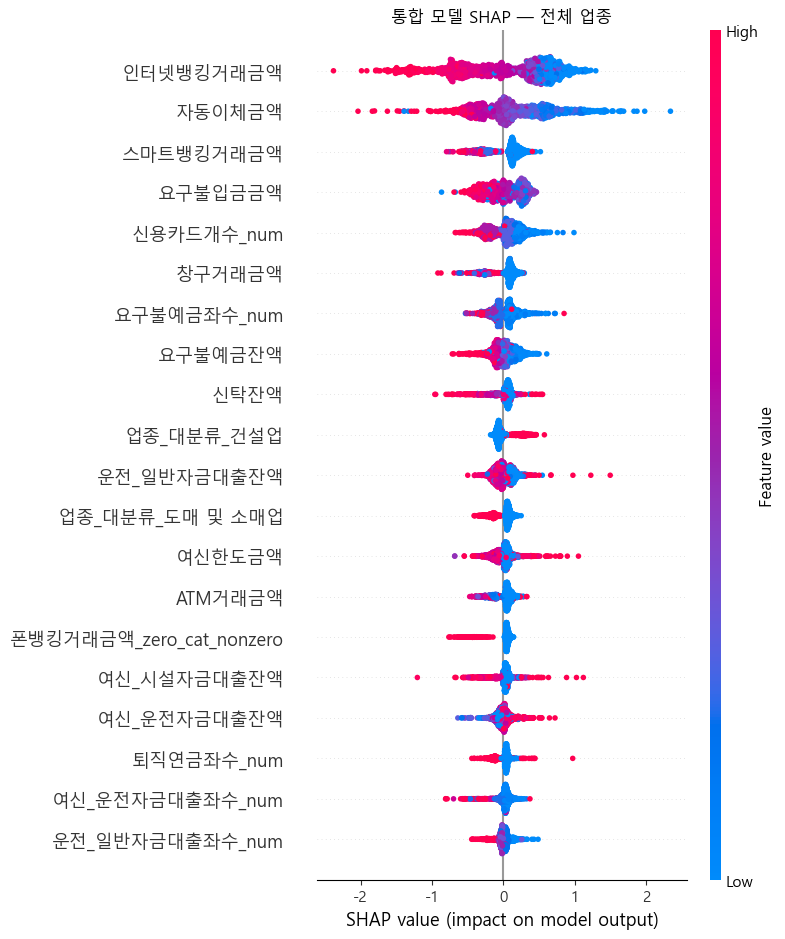

In [21]:
# ============================================================
# SHAP / Feature Importance
# ============================================================

# 업종별 Feature Importance Top 20은 SHAP 설치 여부와 무관하게 출력
for ind, info in IND_MODELS.items():
    print(f'\n[{ind}] Feature Importance Top 20')
    display(info['feature_importance'].head(20))

# 통합 모델 SHAP은 shap 패키지가 있을 때만 실행
try:
    import shap

    prep = INT_PIPE.named_steps['prep']
    lgbm = INT_PIPE.named_steps['model']

    sample_n = min(1500, len(df_test))
    Xte_raw = df_test.sample(sample_n, random_state=RANDOM_STATE).copy()
    Xte_int = apply_clip_log(Xte_raw, NUM_FEAT_ALL, INT_bounds, INT_logset)[INT_kept + INT_cat]

    Xt_transformed = prep.transform(Xte_int)
    if hasattr(Xt_transformed, 'toarray'):
        Xt = Xt_transformed.toarray()
    else:
        Xt = np.asarray(Xt_transformed)

    ohe = prep.named_transformers_.get('cat') if 'cat' in prep.named_transformers_ else None
    feature_names = (list(ohe.get_feature_names_out(INT_cat)) if ohe is not None else []) + INT_kept

    explainer = shap.TreeExplainer(lgbm)
    shap_values = explainer.shap_values(Xt)

    if isinstance(shap_values, list):
        shap_values = shap_values[1]

    shap_values = np.asarray(shap_values)

    if shap_values.ndim == 3:
        shap_values = shap_values[:, :, 1]

    shap.summary_plot(
        shap_values,
        Xt,
        feature_names=feature_names,
        show=False,
        max_display=20
    )
    plt.title('통합 모델 SHAP — 전체 업종')
    plt.tight_layout()
    plt.show()

    SHAP_INT = {
        'shap': shap_values,
        'X': Xt,
        'names': feature_names
    }

except Exception as e:
    print('SHAP 계산 스킵:', e)
    SHAP_INT = None

## 단계5 — 중요 변수 기반 EDA (y=0 vs y=1, df_model 기준 원본단위)

In [22]:
# 업종별 상위 중요 수치형 변수에 대해 y=0/1 비교 (clip/log 전 원본 dfx 기준)
EDA_ROWS = []
for ind, info in IND_MODELS.items():
    sub = dfx[dfx['업종_대분류']==ind]
    # FI 상위 중 수치형 원본 변수만 (one-hot 더미 제외)
    top_num = [f for f in info['feature_importance']['feature'] if f in NUM_FEAT_ALL][:8]
    print(f'\n[{ind}] 주요 수치형 변수 y=0 vs y=1')
    for f in top_num:
        g0 = sub.loc[sub['y']==0, f]; g1 = sub.loc[sub['y']==1, f]
        row = {'업종':ind,'변수':f,
               'y0_평균':round(g0.mean(),2),'y1_평균':round(g1.mean(),2),
               'y0_중앙':round(g0.median(),2),'y1_중앙':round(g1.median(),2),
               '차이':round(g1.mean()-g0.mean(),2),
               '차이율':round((g1.mean()-g0.mean())/(abs(g0.mean())+1e-9),3)}
        EDA_ROWS.append(row)
    print(pd.DataFrame([r for r in EDA_ROWS if r['업종']==ind]).to_string(index=False))

# high-zero categorical 변수의 y=0/1 비율 차이
print('\n[high-zero zero_cat 변수의 y=1 비율 (nonzero일 때)]')
for c in high_zero_cat_cols[:10]:
    if c in dfx.columns:
        nz = dfx[dfx[c]=='nonzero']
        if len(nz)>0:
            print(f'  {c}: nonzero일 때 y=1 비율 {nz["y"].mean()*100:.1f}% (전체 {dfx["y"].mean()*100:.1f}%)')


[제조업] 주요 수치형 변수 y=0 vs y=1
 업종          변수   y0_평균   y1_평균  y0_중앙  y1_중앙      차이    차이율
제조업      자동이체금액  244.20   76.58   30.0    8.2 -167.62 -0.686
제조업 여신_운전자금대출잔액 1762.66 1017.08  520.0  300.0 -745.58 -0.423
제조업 운전_일반자금대출잔액  963.34  652.22  400.0  250.0 -311.12 -0.323
제조업     요구불예금잔액  210.11   81.18   33.0    3.8 -128.93 -0.614
제조업   인터넷뱅킹거래금액  614.63  245.59  160.0   13.0 -369.04 -0.600
제조업     요구불입금금액 1158.69  380.53  220.0   32.0 -778.16 -0.672
제조업        신탁잔액  300.88  104.83    0.0    0.0 -196.05 -0.652
제조업    신용카드사용금액    6.95    3.60    3.9    1.2   -3.35 -0.482

[도매 및 소매업] 주요 수치형 변수 y=0 vs y=1
      업종          변수   y0_평균  y1_평균  y0_중앙  y1_중앙      차이    차이율
도매 및 소매업      자동이체금액  274.71  21.24   23.0   5.10 -253.47 -0.923
도매 및 소매업     요구불예금잔액  132.18  64.04   22.0   2.10  -68.13 -0.515
도매 및 소매업 여신_운전자금대출잔액  775.09 536.47  240.0 160.00 -238.62 -0.308
도매 및 소매업     요구불입금금액 1140.89 174.41  310.0  31.00 -966.49 -0.847
도매 및 소매업    신용카드사용금액    6.79   4.18    3.2   0.58   -2.61 -0.384


## 5-3. 출력물 정리

In [ ]:
# ============================================================
# 출력물 정리
# ============================================================

print('=' * 70)
print('15-1. 데이터 요약')
print('=' * 70)
print('NOTEBOOK_NAME       :', NOTEBOOK_NAME)
print('전체 df shape       :', df.shape)
print('df_model shape      :', df_model.shape)
print('법인ID 수           :', df_model['법인ID'].nunique())
print('기간                :', df['기준년월'].min(), '~', df['기준년월'].max())
print('warm-up 행 수       :', (~df['y_available']).sum())
print('y 분포              :', dict(df_model['y'].value_counts()))

print('\n업종별 행 수')
display(dfx['업종_대분류'].value_counts().to_frame('row_count'))

print('\n업종별 법인 수')
display(dfx.groupby('업종_대분류')['법인ID'].nunique().sort_values(ascending=False).to_frame('corp_count'))

print('\n' + '=' * 70)
print('15-2. 0비율 처리 요약')
print('=' * 70)
print('100% 0 제거 변수 수        :', len(zero_100_cols))
print('0비율 85%↑ zero_cat 변수 수:', len(HIGH_ZERO_NUMERIC_DROP_COLS))
print('zero_cat 컬럼              :', high_zero_cat_cols[:50])
print('high-zero 원본 제거 컬럼    :', HIGH_ZERO_NUMERIC_DROP_COLS[:50])

print('\n' + '=' * 70)
print('15-3. 업종별 모델 성능')
print('=' * 70)
display(res_ind)

print('\n' + '=' * 70)
print('15-4. 통합/앙상블 성능')
print('=' * 70)
display(res_ens)

print('\n' + '=' * 70)
print('15-5. 업종별 Top Feature')
print('=' * 70)
for ind, info in IND_MODELS.items():
    print(f'\n[{ind}]')
    display(info['feature_importance'].head(10))

print('\n' + '=' * 70)
print('15-6. EDA 요약')
print('=' * 70)

if EDA_ROWS:
    eda_df = pd.DataFrame(EDA_ROWS).reindex(columns=[
        '업종', '변수',
        'y0_평균', 'y1_평균',
        'y0_중앙', 'y1_중앙',
        '차이', '차이율'
    ])
    display(eda_df)
else:
    eda_df = pd.DataFrame()
    print('EDA_ROWS가 비어 있습니다.')

# 결과 저장
res_ind_path = f'{NOTEBOOK_NAME}_업종별성능.csv'
res_ens_path = f'{NOTEBOOK_NAME}_앙상블성능.csv'
eda_path = f'{NOTEBOOK_NAME}_eda요약.csv'

res_ind.to_csv(res_ind_path, index=False, encoding='utf-8-sig')
res_ens.to_csv(res_ens_path, index=False, encoding='utf-8-sig')
eda_df.to_csv(eda_path, index=False, encoding='utf-8-sig')

print('\n저장 완료:')
print(' -', res_ind_path)
print(' -', res_ens_path)
print(' -', eda_path)

15-1. 데이터 요약
NOTEBOOK_NAME       : final7
전체 df shape       : (121392, 108)
df_model shape      : (97788, 108)
법인ID 수           : 3372
기간                : 202301 ~ 202512
warm-up 행 수       : 20232
y 분포              : {0: 58131, 1: 39657}

업종별 행 수


,row_count
업종_대분류,
제조업,31697
도매 및 소매업,20474
건설업,16907
부동산업,7801



업종별 법인 수


,corp_count
업종_대분류,
제조업,1093
도매 및 소매업,706
건설업,583
부동산업,269



15-2. 0비율 처리 요약
100% 0 제거 변수 수        : 4
0비율 85%↑ zero_cat 변수 수: 30
zero_cat 컬럼              : ['운전_당좌대출잔액_zero_cat', '운전_외상매출채권담보대출잔액_zero_cat', '운전_무역금융잔액_zero_cat', '운전_외상매출채권담보대출좌수_num_zero_cat', '외환_수출실적금액_zero_cat', '외환_수출실적거래건수_num_zero_cat', '운전_무역금융좌수_num_zero_cat', '수익증권잔액_zero_cat', '운전_당좌대출좌수_num_zero_cat', '시설_에너지절약시설대출잔액_zero_cat', '시설_에너지절약시설대출좌수_num_zero_cat', '외환_수입실적거래건수_num_zero_cat', '외환_수입실적금액_zero_cat', '운전_할인어음잔액_zero_cat', '수익증권좌수_num_zero_cat', '체크카드사용금액_zero_cat', '운전_기업구매자금대출잔액_zero_cat', '운전_할인어음좌수_num_zero_cat', '지역_결측_여부_zero_cat', '운전_기업구매자금대출좌수_num_zero_cat', '시설_기타시설자금대출잔액_zero_cat', '시설_기타시설자금대출좌수_num_zero_cat', '적립식예금잔액_zero_cat', '운전_기타운전자금대출잔액_zero_cat', '거치식예금잔액_zero_cat', '운전_기타운전자금대출좌수_num_zero_cat', '적립식예금좌수_num_zero_cat', '거치식예금좌수_num_zero_cat', '폰뱅킹거래금액_zero_cat', '폰뱅킹거래건수_num_zero_cat']
high-zero 원본 제거 컬럼    : ['운전_당좌대출잔액', '운전_외상매출채권담보대출잔액', '운전_무역금융잔액', '운전_외상매출채권담보대출좌수_num', '외환_수출실적금액', '외환_수출실적거래건수_num', '운전_무역금융좌수_num', '수익증권잔액', '운전_

...

,feature,importance
65,요구불예금잔액,1630
76,자동이체금액,1600
77,요구불입금금액,1127
78,요구불출금금액,1079
70,시설_일반자금대출잔액,1073
73,인터넷뱅킹거래금액,1048
69,여신_운전자금대출잔액,815
71,신용카드사용금액,652
74,스마트뱅킹거래금액,602
68,여신한도금액,374



15-6. EDA 요약


,업종,변수,y0_평균,y1_평균,y0_중앙,y1_중앙,차이,차이율
0,제조업,자동이체금액,244.20,76.58,30.00,8.20,-167.62,-0.686
1,제조업,여신_운전자금대출잔액,1762.66,1017.08,520.00,300.00,-745.58,-0.423
2,제조업,운전_일반자금대출잔액,963.34,652.22,400.00,250.00,-311.12,-0.323
3,제조업,요구불예금잔액,210.11,81.18,33.00,3.80,-128.93,-0.614
4,제조업,인터넷뱅킹거래금액,614.63,245.59,160.00,13.00,-369.04,-0.600
5,제조업,요구불입금금액,1158.69,380.53,220.00,32.00,-778.16,-0.672
6,제조업,신탁잔액,300.88,104.83,0.00,0.00,-196.05,-0.652
7,제조업,신용카드사용금액,6.95,3.60,3.90,1.20,-3.35,-0.482
8,도매 및 소매업,자동이체금액,274.71,21.24,23.00,5.10,-253.47,-0.923
9,도매 및 소매업,요구불예금잔액,132.18,64.04,22.00,2.10,-68.13,-0.515



저장 완료:
 - final7_업종별성능.csv
 - final7_앙상블성능.csv
 - final7_eda요약.csv


: 